In [46]:
# Install datasets Library (if not already installed)
# !pip install -U datasets

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  # we will use this for plotting

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [47]:
df.loc[:, 'salary_rate':'salary_hour_avg'].dropna(subset='salary_rate')

,salary_rate,salary_year_avg,salary_hour_avg
28,year,109500.0,NaN
43,hour,NaN,97.5
51,hour,NaN,72.5
77,year,140000.0,NaN
92,year,120000.0,NaN
...,...,...,...
785624,year,139216.0,NaN
785641,year,150000.0,NaN
785648,year,221875.0,NaN
785682,year,157500.0,NaN


In [48]:
df = df.drop_duplicates(subset= ['job_title', 'company_name'])
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785735,Senior Data Engineer,Senior Data Engineer,"Berlin, Jerman",melalui Top County Careers,Pekerjaan tetap,False,Germany,2023-03-13 06:19:07,False,False,Germany,NaN,NaN,NaN,Pure App,"['sql', 'python', 'bigquery', 'aws', 'airflow'...","{'cloud': ['bigquery', 'aws'], 'libraries': ['..."
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"


In [49]:
job_salary = df.groupby('job_title_short')[['salary_year_avg','salary_hour_avg']].median()
job_salary


,salary_year_avg,salary_hour_avg
job_title_short,,
Business Analyst,86400.0,39.750000
Cloud Engineer,90000.0,40.000000
Data Analyst,90000.0,32.500000
Data Engineer,125000.0,59.000000
Data Scientist,126000.0,46.660000
Machine Learning Engineer,104668.0,42.500000
Senior Data Analyst,111175.0,45.520000
Senior Data Engineer,147500.0,64.440002
Senior Data Scientist,155000.0,48.757502


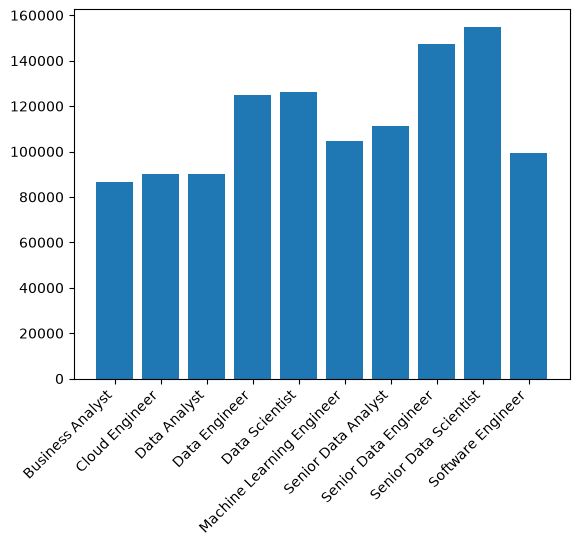

In [50]:
plt.bar(job_salary.index, job_salary['salary_year_avg'])
plt.xticks(rotation = 45, ha = 'right')
plt.show()

In [51]:
df.sample(15)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
447905,Data Analyst,Data Analyst (m/w/d),"Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-08-25 14:25:06,True,False,Germany,NaN,NaN,NaN,AERTiCKET Gruppe,"['excel', 'sap']","{'analyst_tools': ['excel', 'sap']}"
426729,Senior Data Scientist,Senior Data Scientist,"Cincinnati, OH",via Trabajo.org,Full-time,False,"Illinois, United States",2023-02-10 16:21:55,False,False,United States,NaN,NaN,NaN,8451,"['python', 'azure', 'databricks', 'spark', 'ha...","{'analyst_tools': ['tableau', 'power bi'], 'cl..."
676613,Data Analyst,Data Quality Analyst Jobfeed,"Amsterdam, Netherlands",via LinkedIn,Full-time,False,Netherlands,2023-04-06 10:25:44,False,False,Netherlands,NaN,NaN,NaN,Textkernel,"['python', 'r', 'elasticsearch']","{'databases': ['elasticsearch'], 'programming'..."
731954,Data Analyst,Data Management & Control Analyst,"Dublin, Ireland",via LinkedIn,Full-time,False,Ireland,2023-11-16 21:31:01,True,False,Ireland,NaN,NaN,NaN,Elavon Europe,NaN,NaN
152407,Data Analyst,Data Analyst and Intelligence Executive,"County Durham, UK",via WJHL Jobs,Full-time,False,United Kingdom,2023-04-14 08:54:36,True,False,United Kingdom,NaN,NaN,NaN,JSM Recruitment Limited,NaN,NaN
753969,Cloud Engineer,Senior Engineer Azure AD,"Mexico City, CDMX, Mexico",via BeBee México,Full-time,False,Mexico,2023-06-07 20:52:44,True,False,Mexico,NaN,NaN,NaN,System Soft Technologies,"['azure', 'windows', 'sharepoint']","{'analyst_tools': ['sharepoint'], 'cloud': ['a..."
362295,Software Engineer,Engineering Support Specialist,"Warsaw, Poland",via Energy Jobline,Full-time,False,Poland,2023-01-04 23:38:30,True,False,Poland,NaN,NaN,NaN,Crystal Equation,"['php', 'javascript', 'python', 'sql', 'linux']","{'os': ['linux'], 'programming': ['php', 'java..."
582347,Data Scientist,Data Scientist. Job in Indianapolis My Valley ...,"Indianapolis, IN",via My Valley Jobs Today,Full-time,False,Georgia,2023-03-29 10:18:59,False,False,United States,NaN,NaN,NaN,ASGN Incorporated,"['go', 'sql', 'azure', 'sap', 'alteryx']","{'analyst_tools': ['sap', 'alteryx'], 'cloud':..."
243319,Data Engineer,Lead Data Engineer Fmd Backend,"Zaragoza, Spain",via Trabajo.org,Full-time,False,Spain,2023-05-27 07:12:45,False,False,Spain,NaN,NaN,NaN,Buscojobs ES Premium,"['snowflake', 'aws', 'oracle']","{'cloud': ['snowflake', 'aws', 'oracle']}"
438439,Data Analyst,Data Analyst (Real Estate),Singapore,via LinkedIn,Full-time,False,Singapore,2023-02-03 16:47:05,True,False,Singapore,NaN,NaN,NaN,Salt Singapore,"['sql', 'spreadsheet']","{'analyst_tools': ['spreadsheet'], 'programmin..."


In [52]:
df_job_country_salary = df.pivot_table(values='salary_year_avg', columns='job_title_short', index='job_country', aggfunc='mean')
df_job_country_salary

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,56700.000000,NaN,69962.500000,NaN,NaN,NaN,NaN,NaN
Algeria,NaN,NaN,NaN,45000.000000,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.000000,197500.000,92785.250000,84557.500000,115600.000000,85514.500000,NaN,147500.000000,NaN,174500.000000
Armenia,NaN,NaN,NaN,52500.000000,NaN,87021.000000,NaN,NaN,NaN,NaN
Australia,87666.666667,110000.000,102875.000000,111686.214286,145343.200000,106357.250000,71280.000000,87848.666667,157500.000000,140655.833333
...,...,...,...,...,...,...,...,...,...,...
United Kingdom,43575.000000,NaN,92895.285714,113770.647059,99451.907895,139564.428571,111393.000000,143750.000000,120785.571429,106825.000000
United States,96081.254277,120313.625,93850.983449,133459.188206,139474.254639,155721.347458,116328.812635,150006.138352,160483.288414,137730.834175
Uruguay,NaN,NaN,NaN,NaN,NaN,50000.000000,NaN,NaN,NaN,NaN


In [53]:
top_countries = df['job_country'].value_counts().head().index
top_countries

Index(['United States', 'India', 'France', 'United Kingdom', 'Germany'], dtype='str', name='job_country')

In [54]:
df_job_country_salary = df_job_country_salary.loc[top_countries]
job_titles = ['Business Analyst', 'Data Analyst', 'Data Scientist']
df_job_country_salary = df_job_country_salary[job_titles]
df_job_country_salary

job_title_short,Business Analyst,Data Analyst,Data Scientist
job_country,,,
United States,96081.254277,93850.983449,139474.254639
India,82255.125000,100381.401408,110750.656250
France,81158.333333,84859.333333,96858.766667
United Kingdom,43575.000000,92895.285714,99451.907895
Germany,76955.000000,106087.735294,112812.883333


Text(0, 0.5, 'Salary ($USD)')

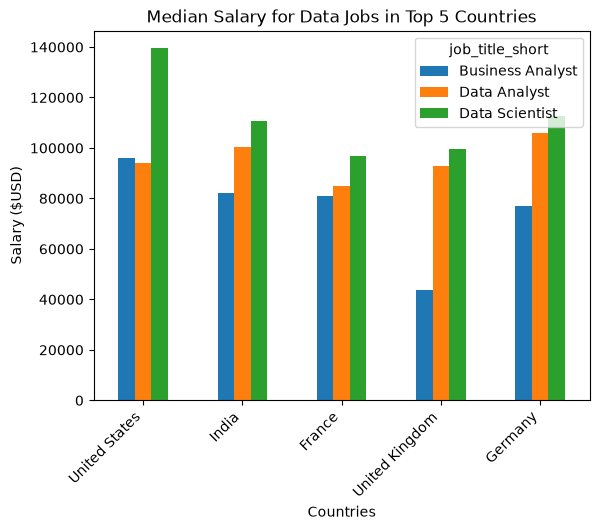

In [55]:
df_job_country_salary.plot(kind='bar')
plt.title('Median Salary for Data Jobs in Top 5 Countries')
plt.xticks(rotation= 45, ha='right')
plt.xlabel('Countries')
plt.ylabel('Salary ($USD)')

In [56]:
df.index.name = 'job_index'

In [57]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_index,,,,,,,,,,,,,,,,,
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [58]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_index,,,,,,,,,,,,,,,,,
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785735,Senior Data Engineer,Senior Data Engineer,"Berlin, Jerman",melalui Top County Careers,Pekerjaan tetap,False,Germany,2023-03-13 06:19:07,False,False,Germany,NaN,NaN,NaN,Pure App,"['sql', 'python', 'bigquery', 'aws', 'airflow'...","{'cloud': ['bigquery', 'aws'], 'libraries': ['..."
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."


In [59]:
df_usa = df[df['job_country'] == 'United States']
df_usa.reset_index(inplace= True)
df_usa

,job_index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
2,5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
3,6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
4,9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122901,785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"['go', 'python', 'r', 'sql', 'oracle', 'window...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
122902,785626,Data Analyst,Data Acquisition Associate,"Tarrytown, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-29 06:01:29,False,False,United States,NaN,NaN,NaN,Planet Group,['microsoft teams'],{'sync': ['microsoft teams']}
122903,785651,Data Scientist,Data Scientist (Supply Chain Security),"Fort Belvoir, VA",via LinkedIn,Full-time,False,Georgia,2023-01-07 07:10:51,False,False,United States,NaN,NaN,NaN,Defense Logistics Agency,['go'],{'programming': ['go']}
122904,785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,NaN,NaN


In [60]:
df_usa.set_index('job_index')

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_index,,,,,,,,,,,,,,,,,
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"['go', 'python', 'r', 'sql', 'oracle', 'window...","{'analyst_tools': ['alteryx', 'power bi', 'tab..."
785626,Data Analyst,Data Acquisition Associate,"Tarrytown, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-29 06:01:29,False,False,United States,NaN,NaN,NaN,Planet Group,['microsoft teams'],{'sync': ['microsoft teams']}
785651,Data Scientist,Data Scientist (Supply Chain Security),"Fort Belvoir, VA",via LinkedIn,Full-time,False,Georgia,2023-01-07 07:10:51,False,False,United States,NaN,NaN,NaN,Defense Logistics Agency,['go'],{'programming': ['go']}


In [95]:
df['job_month'] = df.job_posted_date.dt.month_name()
df_visual = df.pivot_table(index='job_month', columns='job_title_short', aggfunc='size')
#df_visual = df_visual.loc[:,['Business Analyst', 'Data Analyst', 'Data Engineer', 'Data Scientist']]
df_visual

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_month,,,,,,,,,,
April,3424,880,9913,8616,7721,720,1475,1954,1491,3264
August,4075,1141,11833,9212,9663,970,1907,2198,2333,3917
December,3352,1015,9945,8885,8223,1032,1331,1835,1657,3264
February,2709,714,10459,9201,8077,768,1617,2026,1583,2706
January,3806,1036,15070,12571,12351,1012,2329,2754,2612,4053
July,2981,860,10438,8621,8231,843,1525,2144,1800,2894
June,2633,582,10017,8914,7825,704,1392,2126,1651,1705
March,2654,718,10386,9608,7838,739,1501,2046,1646,2952
May,1871,391,8329,7945,6651,576,1200,1868,1346,1528


<Axes: xlabel='job_month'>

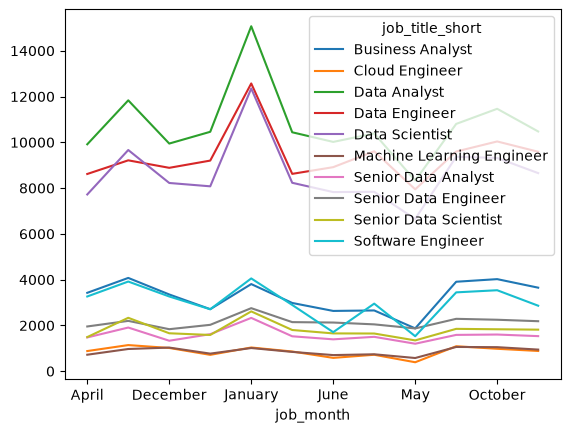

In [96]:
df_visual.plot(kind='line')

In [117]:
df_usa['job_month'] = df_usa.job_posted_date.dt.strftime('%B')

df_visual_usa = df_usa.pivot_table(index='job_month', columns='job_title_short', aggfunc='size')
df_visual_usa = df_visual_usa.reset_index()

df_visual_usa['month_no'] = pd.to_datetime(df_visual_usa['job_month'], format= '%B').dt.month
df_visual_usa = df_visual_usa.sort_values(by= 'month_no')
df_visual_usa = df_visual_usa.drop(columns= 'month_no')
#df_visual_usa = df_visual_usa.loc[:,['job_month','Business Analyst', 'Data Analyst', 'Data Engineer', 'Data Scientist']]
df_visual_usa


job_title_short,job_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
4,January,441,30,5178,1589,3758,53,955,390,817,98
3,February,350,20,3618,1732,2530,48,689,464,546,69
7,March,356,19,3715,1878,2451,53,667,444,573,90
0,April,479,35,3554,1570,2404,40,596,393,437,97
8,May,239,16,2826,1675,2132,38,488,427,428,77
6,June,376,30,3317,1687,2398,39,556,452,545,71
5,July,483,36,3211,1517,2537,53,544,406,569,130
1,August,759,32,4066,1929,3164,51,740,462,798,165
11,September,790,45,3159,2062,2665,96,550,453,562,186
10,October,804,39,3626,1937,2955,75,576,426,562,187


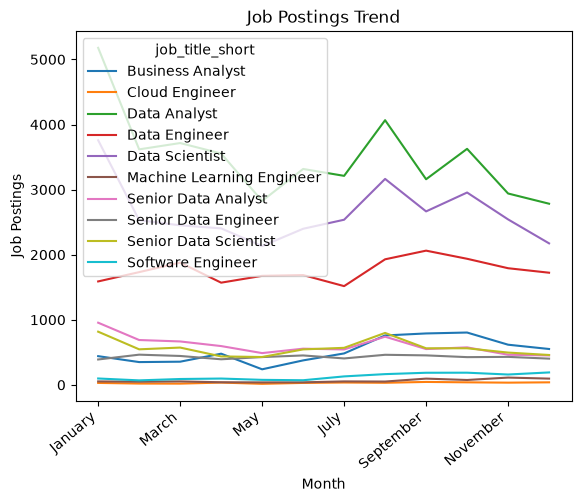

In [118]:
df_visual_usa.plot(kind='line', x= 'job_month')
plt.xticks(rotation= 40, ha= 'right')
plt.title('Job Postings Trend')
plt.xlabel('Month')
plt.ylabel('Job Postings')
plt.show()

In [119]:
df_US_software_pivot = pd.read_csv('https://lukeb.co/software_csv')
df_US_software_pivot = df_US_software_pivot.set_index('job_posted_month')
df_US_software_pivot.index.name = 'job_month'
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [137]:
df_US_merged = df_visual_usa.merge(df_US_software_pivot, on='job_month')
df_US_merged = df_US_merged.set_index('job_month')
df_US_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_month,,,,,,,,,,,,,,
January,441,30,5178,1589,3758,53,955,390,817,98,13619,9827,5108,4348
February,350,20,3618,1732,2530,48,689,464,546,69,11456,9116,7298,4284
March,356,19,3715,1878,2451,53,667,444,573,90,11102,8178,5814,4159
April,479,35,3554,1570,2404,40,596,393,437,97,14037,9209,7232,4220
May,239,16,2826,1675,2132,38,488,427,428,77,12126,8864,6718,4980
June,376,30,3317,1687,2398,39,556,452,545,71,12003,8065,5902,4781
July,483,36,3211,1517,2537,53,544,406,569,130,11914,8061,6839,4344
August,759,32,4066,1929,3164,51,740,462,798,165,11571,8191,7413,4104
September,790,45,3159,2062,2665,96,550,453,562,186,14016,8447,6139,4094


In [143]:
top_5_jobs = df_US_merged.sum().sort_values(ascending= False).head()
top_5_jobs = top_5_jobs.index.to_list()
top_5_jobs


['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Analyst']

(0.0, 20000.0)

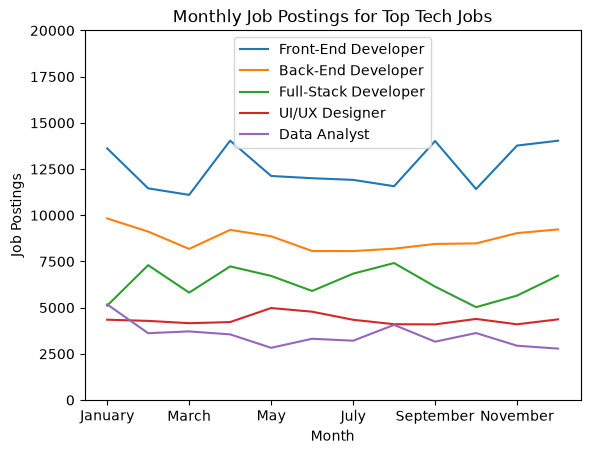

In [146]:
df_US_merged[top_5_jobs].plot(kind= 'line')
plt.title('Monthly Job Postings for Top Tech Jobs')
plt.xlabel('Month')
plt.ylabel('Job Postings')
plt.ylim(0, 20000)